In [1]:
%load_ext autoreload
%autoreload 2

In [2]:


from Nozzle_2D_checkpoint4_2 import Nozzle
import matplotlib.pyplot as plt
import numpy as np
import pickle



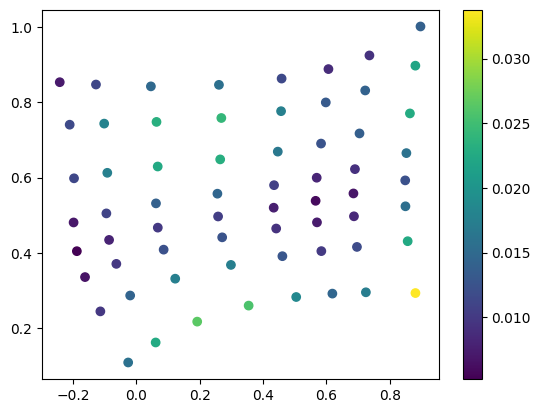

In [5]:
SUPERCOARSE = Nozzle("inputs/RAMP_inputs.nml")
SUPERCOARSE.CFL = .1


self = SUPERCOARSE 
self.CFL = .0000001
self.iter_max = 78000

# RUN MEDIUM SIMULATION
self.set_arrays()
self.load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL2/Meshes/curv2d9.grd")
#self.set_curved_geometry()
self.set_normals()
self.compute_all_areas(visualize=True)
self.is_foil = False


In [183]:
np.max(self.A_left)

0.031242165902602478

In [184]:
self.get_normal_directions("left")[0][2,:]


array([-0.        , -0.15213176, -0.38153872, -0.52476846, -0.62379563,
       -0.68765151, -0.71557801, -0.71933218, -0.7276586 , -0.76078074,
       -0.81267744, -0.86782472, -0.90632056, -0.94071136, -0.96902375,
       -0.98450446, -0.99246063, -0.99609422, -0.99737574, -0.99733961,
       -0.99640605, -0.99437843, -0.99200743, -0.98978598, -0.98782328,
       -0.98619522, -0.98494501, -0.98408686, -0.98361043, -0.98349003,
       -0.98369141, -0.98417065, -0.98488528, -0.98578786, -0.98683601,
       -0.98798723, -0.9892024 , -0.990446  , -0.99168481, -0.99289068,
       -0.9940378 , -0.99510821, -0.99608408, -0.99695317, -0.99770837,
       -0.99834627, -0.99886635, -0.99927389, -0.99957673, -0.99978574,
       -0.99991523, -0.99998126, -1.        ])

In [6]:
import pyvista as pv
import numpy as np

# Suppose you have a grid of size (NI, NJ)
grid = pv.StructuredGrid(self.x, self.y, np.zeros_like(self.x))  # shape should be (NI, NJ, 1) for 2D
#normals = grid.compute_normals(cell_normals=True)
#grid.cell_data["Normals"]

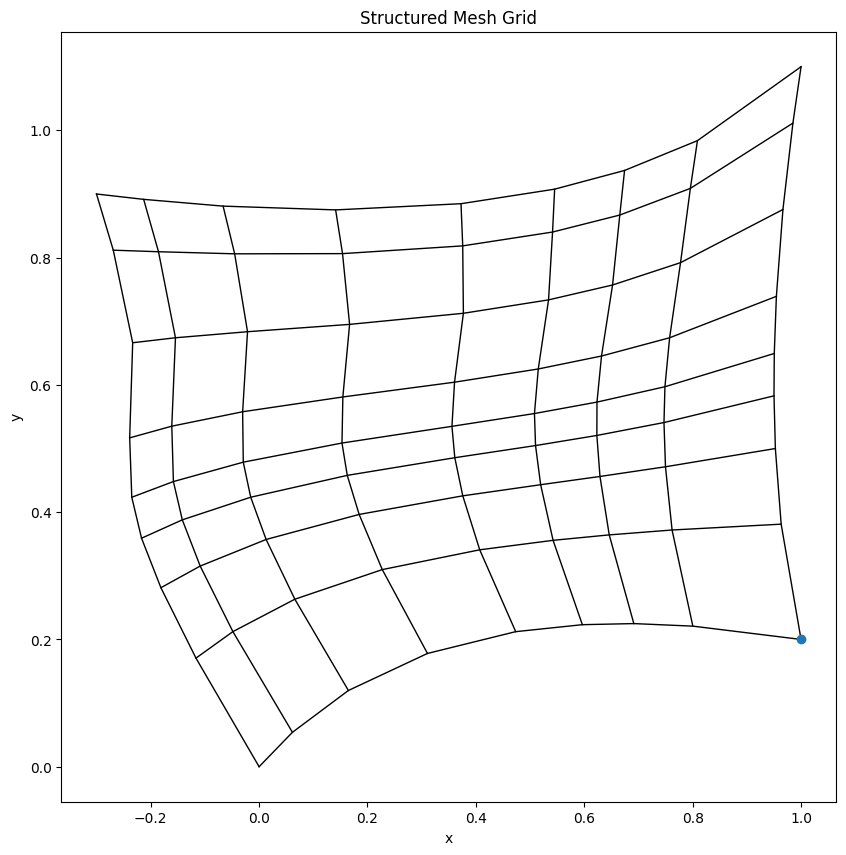

In [7]:
xx = self.x
yy = self.y
plt.figure(figsize=(10, 10))

# Vertical lines
for j in range(xx.shape[1]):
    plt.plot(xx[:, j], yy[:, j], 'k-', lw=1)

# Horizontal lines
for i in range(xx.shape[0]):
    plt.plot(xx[i, :], yy[i, :], 'k-', lw=1)
tempxx,tempyy = xx[::-1,:],yy[::-1,:]

np.savetxt("test_xx.csv",tempxx,delimiter=",")
np.savetxt("test_yy.csv",tempyy,delimiter=",")

#plt.scatter(midpointxx,midpointyy)
plt.plot(tempxx[0,0],tempyy[0,0],"o")
plt.title("Structured Mesh Grid")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [187]:
np.savetxt("test_xx.csv",self.x,delimiter=",")
np.savetxt("test_yy.csv",self.y,delimiter=",")

In [188]:
import f90nml
nml = f90nml.read("inputs/Medium_inputs.nml")

In [189]:
import json
with open('params.json', 'w') as f:
    json.dump(nml, f)

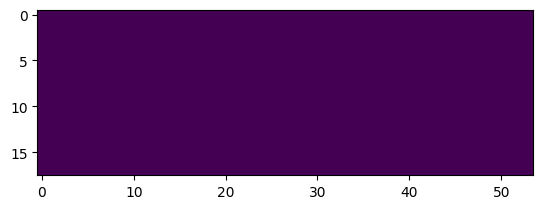

In [190]:
plt.imshow(self.V[0])

In [191]:
#self.set_initial_conditions2(direction="right",boundary_mach=.01)
self.set_initial_foil_conditions(boundary_mach=.0001)

self.set_ramp_inflow(boundary_mach=.1)
#self.set_inflow_conditions(direction="right",boundary_mach=.75)
self.V[:, -2, :] = self.V[:,-1,:]

In [192]:
F_plus_1_2 = self.f_convective(direction="right")+self.f_pressure_flux(direction="right")
F_minus_1_2 = self.f_convective(direction="left")+self.f_pressure_flux(direction="left")
F_UP = self.f_convective(direction="up")+self.f_pressure_flux(direction="up")
F_DOWN = self.f_convective(direction="down")+self.f_pressure_flux(direction="down")



 # +F_UP[:,1:,:]+F_DOWN[:,0:-1,:]

In [193]:
F_plus_1_2.shape

(4, 16, 53)

In [194]:
self.residual[1]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.],
    

In [240]:
self.iteration_step()


array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  5.77845873e-11,  2.53382609e-11, ...,
          2.71875170e-19,  3.03715565e-18,  0.00000000e+00],
        [ 0.00000000e+00, -1.48479826e-08, -1.06907250e-08, ...,
         -3.42387297e-19,  4.08463261e-18,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  6.03841400e-06, -1.38008019e-05, ...,
          7.84158264e-06,  7.51505561e-06,  0.00000000e+00],
        [ 0.00000000e+00,  4.40095485e-05,  3.35250547e-05, ...,
          1.15342258e-05,  1.10769677e-05,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  2.94180359e-09, -4.07731585e-09, ...,
          4.39673793e-17, -2.17936837e

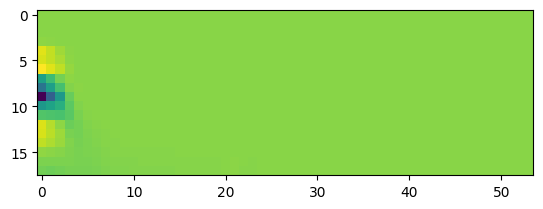

In [241]:
plt.imshow(self.V[1])

In [197]:
(F_minus_1_2[:,:,:-1])+F_plus_1_2[:,:,1:]

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 2.91745295e-03,  3.66244788e-03,  3.89123352e-03, ...,
          1.98089190e-06,  9.72521165e-07,  2.87420394e-07]],

       [[ 3.08150871e+01,  9.38111951e+00,  4.56838840e+00, ...,
          3.13596273e-03,  1.56706753e-03,  5.28509916e-04],
        [ 1.39933987e+01,  1.38072836e+01,  8.02105362e+00, ...,
          7.95806131e-03,  4.05691599e

In [198]:
(((F_minus_1_2[:,:,:-1])*self.A_left+\
(F_plus_1_2[:,:,1:])*self.A_right+\
F_UP[:,1:,:]*self.A_top+\
F_DOWN[:,0:-1,:]*self.A_bottom)[1])

array([[-2.77555756e-17,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -1.11022302e-16,  0.00000000e+00,
         2.22044605e-16,  0.00000000e+00, -4.44089210e-16,
        -4.44089210e-16,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -5.55111512e-17, -2.77555756e-17,
         2.77555756e-17, -4.16333634e-17,  5.55111512e-17,
         1.52655666e-16,  0.00000000e+00, -1.35308431e-16,
        -3.90312782e-17,  9.71445147e-17, -1.14491749e-16,
         5.55111512e-17, -9.54097912e-17,  1.02348685e-16,
        -1.05818132e-16,  1.04083409e-17,  3.81639165e-17,
         2.28983499e-16, -2.18575158e-16, -8.67361738e-17,
        -5.55111512e-17,  2.94902991e-16,  1.38777878e-17,
        -3.43475248e-16,  2.32452946e-16,  1.14491749e-16,
        -1.28369537e-16, -4.16333634e-17, -4.51028104e-17,
         1.07552856e-16, -2.53269627e-16,  1.00613962e-16,
         4.16333634e-16, -3.33066907e-16,  2.08166817e-17,
        -2.46330734e-16,  4.89192020e-16, -3.12250226e-1

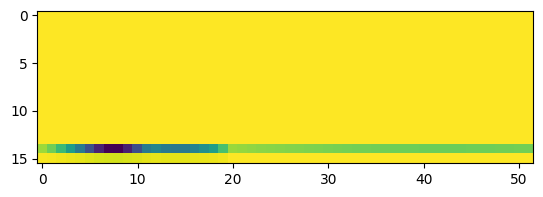

In [230]:
plt.imshow((F_minus_1_2[1][:,:-1])*self.A_left[0]+\
(F_plus_1_2[1][:,1:])*self.A_right[0]+\
(F_UP[1][1:,:])*self.A_top[0]+\
(F_DOWN[1][0:-1,:])*self.A_bottom[0])


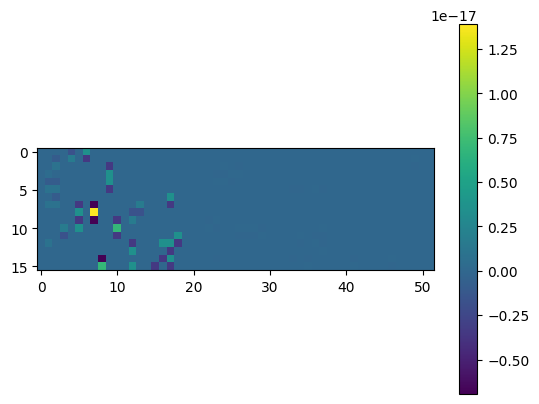

In [200]:
plt.imshow((self.get_normal_directions("left")[0][:,:-1])*self.A_left[0]+\
(self.get_normal_directions("right")[0][:,1:])*self.A_right[0]+\
(self.get_normal_directions("up")[0][1:,:])*self.A_top[0]+\
(self.get_normal_directions("down")[0][0:-1,:])*self.A_bottom[0])
plt.colorbar()

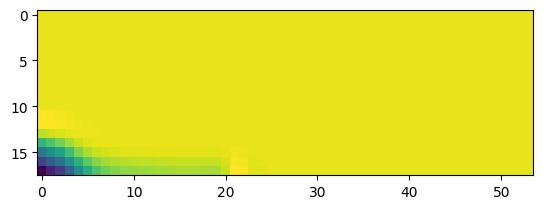

In [232]:
plt.imshow(self.V[1])

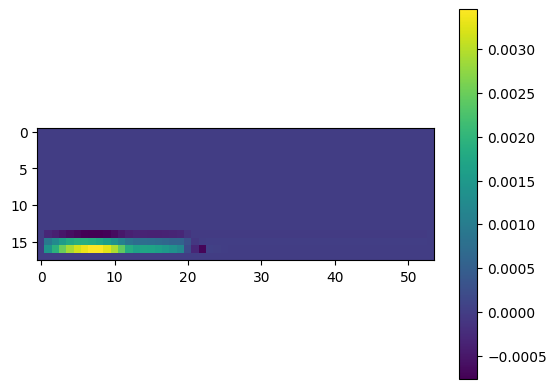

In [225]:
plt.imshow(self.residual[1])
plt.colorbar()

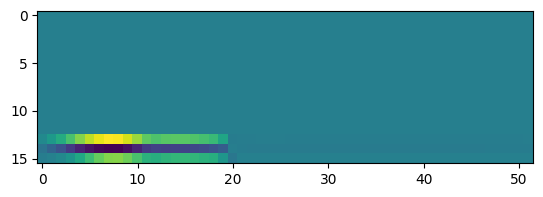

In [203]:
plt.imshow(self.compute_residual_cell()[2])

In [204]:
self.U

array([[[ 7.64911601e-04,  7.64911601e-04,  7.64911601e-04, ...,
          7.64911601e-04,  7.64911601e-04,  7.64911601e-04],
        [ 7.64911601e-04,  7.64911601e-04,  7.64911601e-04, ...,
          7.64911601e-04,  7.64911601e-04,  7.64911601e-04],
        [ 7.64911601e-04,  7.64911601e-04,  7.64911601e-04, ...,
          7.64911601e-04,  7.64911601e-04,  7.64911601e-04],
        ...,
        [ 7.65158304e-04,  7.65136870e-04,  7.65115436e-04, ...,
          7.64909487e-04,  7.64909635e-04,  7.64909784e-04],
        [ 7.65272523e-04,  7.65247996e-04,  7.65223468e-04, ...,
          7.64910596e-04,  7.64910871e-04,  7.64911146e-04],
        [ 7.65380555e-04,  7.65359121e-04,  7.65331500e-04, ...,
          7.64911705e-04,  7.64912107e-04,  7.64912255e-04]],

       [[ 2.22424716e-18,  2.22424716e-18,  0.00000000e+00, ...,
         -5.09806918e-21,  3.17697490e-20,  3.37807247e-20],
        [ 2.22424716e-18,  1.11212358e-18,  0.00000000e+00, ...,
          4.26886691e-21,  2.37082639e

In [205]:

#residual = self.compute_residual_cell()
self.delta_t = .01
R0 = np.linalg.norm(self.iteration_step()[0])


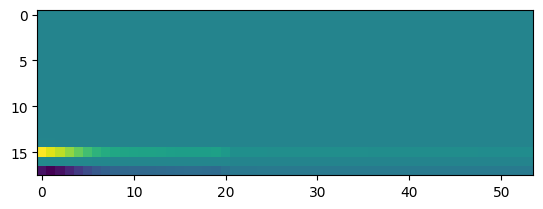

In [206]:
plt.imshow(self.V[1])

In [207]:
self.delta_t = self.CFL



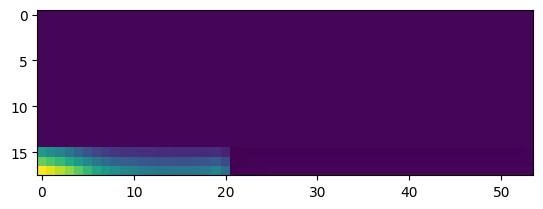

In [208]:
plt.imshow(self.V[3])

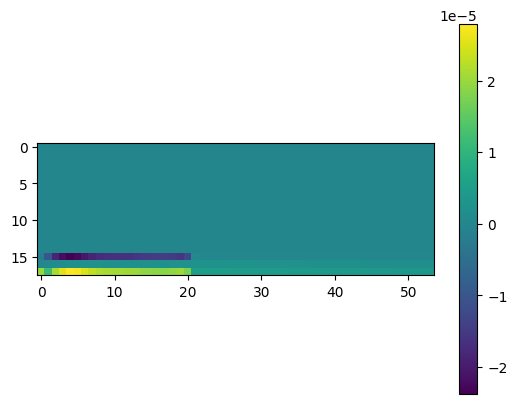

In [209]:
plt.imshow(self.U[2])
plt.colorbar()

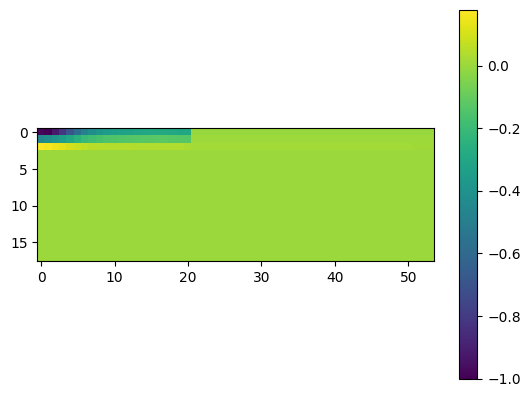

In [210]:
#self.set_inflow_conditions(direction="right",boundary_mach=.75)
self.set_ramp_inflow(boundary_mach=4)
self.delta_t = .000001
self.U = self.primitive_to_conserved(self.V)
R0 = np.linalg.norm(self.iteration_step()[0])
plt.imshow(self.V[1,::-1])
plt.colorbar()

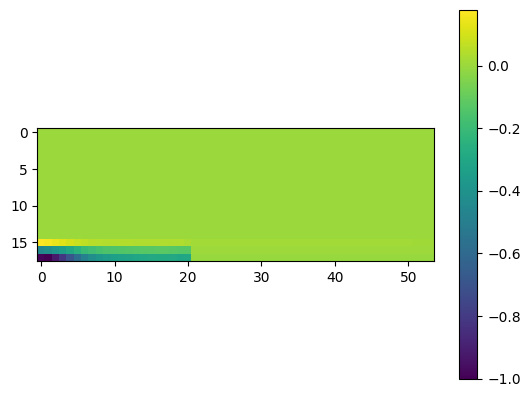

In [211]:
plt.imshow(self.V[1])
plt.colorbar()

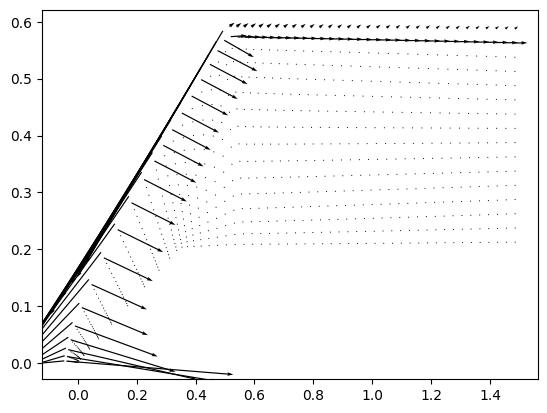

In [212]:
self.plot_primitive("velocity")

In [213]:
#self.V = np.load("checkpoint_V001.npy")
#self.U = np.load("checkpoint_U001.npy")

Iteration0   0.0012874732002235898


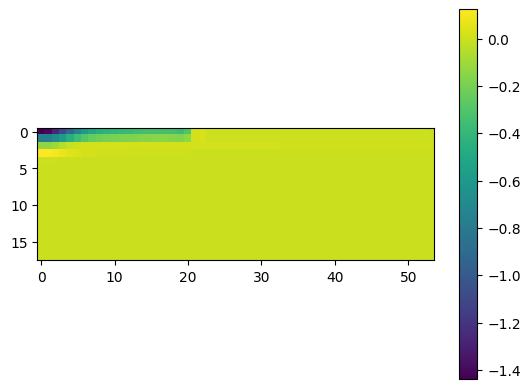

In [214]:
self.CFL = .00001
for i in range(1):
    #self.set_ramp_inflow(boundary_mach=4)
    
    
    R1 = self.iteration_step()

    self.V[:,:,-1] = self.V[:,:,-2]
    self.set_ramp_bcs()
    
    #self.set_foil_inflow(boundary_mach=.2)
    #self.set_normal_bcs()
    #self.V[3] = np.minimum(10e+3,self.V[3])
    print(f"Iteration{i}  ",np.linalg.norm(R1[0])/(R0))
plt.imshow(self.V[1,::-1])
plt.colorbar()


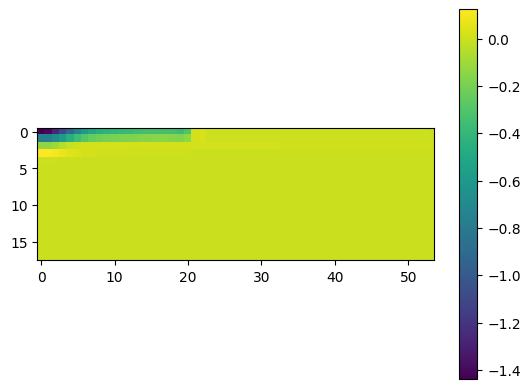

In [215]:

plt.imshow(self.V[1,::-1])
plt.colorbar()

In [216]:
#np.save("checkpoint_V001",self.V)
#np.save("checkpoint_U001",self.U)

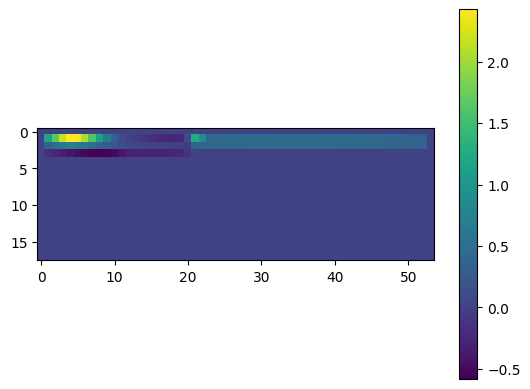

In [217]:
plt.imshow(R1[3,::-1])
plt.colorbar()

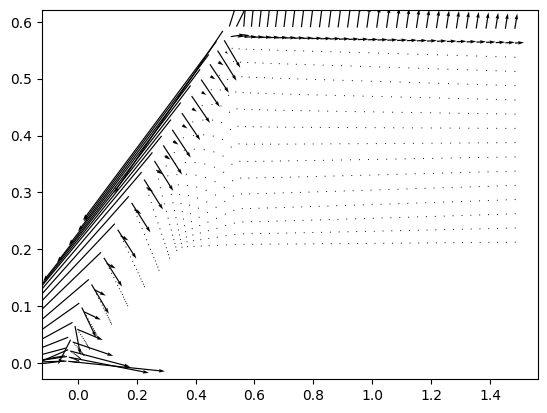

In [218]:
self.plot_primitive("velocity")



In [219]:
v2x = self.V[1,1,1:-1]
v2y = self.V[2,1,1:-1]
u_top,v_top = self.compute_slip_walls(self.downward_S[self.unormal,0,:],\
                                    self.downward_S[self.vnormal,0,:],self.downward_normal[self.unormal,0,:],\
                                        self.downward_normal[self.vnormal,0,:],v2x,v2y)
bottom = [u_top,v_top]

In [220]:
import numpy as np

def polygon_signed_area(P):
    x, y = P[:, 0], P[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - y * np.roll(x, -1))

def polygon_normals_sum(P):
    """
    P: (N,2) array of vertices in order (CCW or CW).
    Returns sum_i (n_hat_i * L_i) where n_hat_i is outward unit normal for edge i.
    For CCW ordering we take outward = right-hand normal.
    """
    P = np.asarray(P, dtype=float)
    if polygon_signed_area(P) < 0:  # ensure CCW
        P = P[::-1].copy()

    N = len(P)
    total = np.zeros(2)
    for i in range(N):
        p0 = P[i]
        p1 = P[(i + 1) % N]
        e = p1 - p0
        L = np.linalg.norm(e)
        if L == 0:
            raise ValueError("Degenerate edge of zero length.")
        dx, dy = e
        # CCW polygon: outward unit normal is the right normal
        n_hat = np.array([dy, -dx]) / L
        total += n_hat * L  # equals [dy, -dx]
    return total

# ----- Example: 2D polygon with 4 arbitrary points -----
pts = np.array([
    [0.2, 0.1],
    [2.0, 0.3],
    [1.8, 1.5],
    [0.1, 1.2],
], dtype=float)

sum_vec = polygon_normals_sum(pts)
print("2D polygon sum of (unit_normal * edge_length):", sum_vec)
print("Magnitude:", np.linalg.norm(sum_vec))

# Optional: assert it's near zero within roundoff
assert np.linalg.norm(sum_vec) < 1e-12


2D polygon sum of (unit_normal * edge_length): [ 0.00000000e+00 -1.38777878e-16]
Magnitude: 1.3877787807814457e-16


In [221]:
import numpy as np

def polygon_signed_area(P):
    """Signed area of polygon (positive if CCW)."""
    area = 0.0
    N = len(P)
    for i in range(N):
        x0, y0 = P[i]
        x1, y1 = P[(i + 1) % N]   # wrap around
        area += x0 * y1 - y0 * x1
    return 0.5 * area

def polygon_normals_sum(P):
    """
    Compute sum of (unit normal * edge length) for polygon edges.
    Ensures CCW ordering so outward normals are consistent.
    """
    P = np.asarray(P, dtype=float)
    if polygon_signed_area(P) < 0:   # if CW, flip to CCW
        P = P[::-1].copy()

    total = np.zeros(2)
    N = len(P)
    for i in range(N):
        p0 = P[i]
        p1 = P[(i + 1) % N]   # wrap to start
        e = p1 - p0
        L = np.linalg.norm(e)
        dx, dy = e
        # outward unit normal (right-hand normal for CCW polygon)
        n_hat = np.array([dy, -dx]) / L
        total += n_hat * L
    return total

# ----- Example: 4 arbitrary points -----
pts = np.array([
    [-0.2, 0.1],
    [-2.0, 0.3],
    [-1.8, 1.5],
    [-0.1, 1.2],
])

print("Signed area:", polygon_signed_area(pts))

sum_vec = polygon_normals_sum(pts)
print("Sum of (unit_normal * edge_length):", sum_vec)
print("Magnitude:", np.linalg.norm(sum_vec))


Signed area: -2.05
Sum of (unit_normal * edge_length): [ 0.00000000e+00 -1.38777878e-16]
Magnitude: 1.3877787807814457e-16


In [222]:
x0 = self.x[0:-1, 0:-1]
y0 = self.y[0:-1, 0:-1]
x1 = self.x[1:,   0:-1]
y1 = self.y[1:,   0:-1]
x2 = self.x[1:,   1:]
y2 = self.y[1:,   1:]
x3 = self.x[0:-1, 1:]
y3 = self.y[0:-1, 1:]

# 2. Compute signed area using shoelace formula
area = 0.5 * (
    x0 * y1 - x1 * y0 +
    x1 * y2 - x2 * y1 +
    x2 * y3 - x3 * y2 +
    x3 * y0 - x0 * y3
)


In [223]:
area

array([[-2.91541649e-06, -6.68254645e-06, -1.34304285e-05,
        -2.86853466e-05, -6.13854429e-05, -1.25091288e-04,
        -2.26118567e-04, -3.35789633e-04, -3.88949524e-04,
        -3.49611229e-04, -2.52105176e-04, -1.48309159e-04,
        -1.30669311e-04, -1.82793284e-04, -2.34129551e-04,
        -2.89576456e-04, -3.47768481e-04, -4.05721568e-04,
        -4.58773364e-04, -4.93474774e-04, -5.10014103e-04,
        -5.16378654e-04, -5.21215592e-04, -5.27799507e-04,
        -5.34786649e-04, -5.41907245e-04, -5.49100176e-04,
        -5.56342706e-04, -5.63625295e-04, -5.70946589e-04,
        -5.78301381e-04, -5.85691295e-04, -5.93113587e-04,
        -6.00568336e-04, -6.08055879e-04, -6.15574426e-04,
        -6.23125055e-04, -6.30707195e-04, -6.38319059e-04,
        -6.45958605e-04, -6.53627908e-04, -6.61326939e-04,
        -6.69050748e-04, -6.76805206e-04, -6.84586586e-04,
        -6.92402384e-04, -7.00256490e-04, -7.08161170e-04,
        -7.16149475e-04, -7.24274254e-04, -7.32664667e-0

In [224]:
x0 = self.x[0:-1, 0:-1]
y0 = self.y[0:-1, 0:-1]
x1 = self.x[1:,   0:-1]
y1 = self.y[1:,   0:-1]
x2 = self.x[1:,   1:]
y2 = self.y[1:,   1:]
x3 = self.x[0:-1, 1:]
y3 = self.y[0:-1, 1:]

# 2. Compute signed area using shoelace formula
area = 0.5 * (
    x0 * y1 - x1 * y0 +
    x1 * y2 - x2 * y1 +
    x2 * y3 - x3 * y2 +
    x3 * y0 - x0 * y3
)

# 3. Identify clockwise cells
cw_mask = area < 0  # boolean array, shape (NI-1, NJ-1)

# 4. Flip normals for clockwise cells
# Use broadcasting: flip signs of all 4 face normals where area < 0

# Expand mask to (1, NI-1, NJ-1) so it can broadcast with shape (4, NI-1, NJ-1)
cw_mask_exp = cw_mask[np.newaxis, :, :]

# Flip signs where needed
self.downward_normal[:, :, cw_mask] *= -1
self.upward_normal[:, :, cw_mask]   *= -1
self.leftward_normal[:, :, cw_mask] *= -1
self.rightward_normal[:, :, cw_mask]*= -1

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed